### Import required modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
    
import numpy as np

sns.set_style("whitegrid")

## Load all dataset using python

In [2]:
train_df = pd.read_csv("./datasets/train.csv")
val_df = pd.read_csv("./datasets/val.csv")
test_df = pd.read_csv("./datasets/test.csv")

train_df.head()

,Year,dengue_total,Location,Month,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,daily_rain_density,average_humidity,avg_soil_moisture,avg_soil_temperature,avg_snowfall,avg_precipitation
0,2024,0,KALIKOT,May,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870,high,extreme,high,low,none,high
1,2022,0,PARSA,Feb,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333,moderate,high,moderate,high,none,moderate
2,2024,19,SALYAN,Sep,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000,low,high,high,low,none,low
3,2022,1,BAJHANG,Jan,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613,no,low,high,low,light,low
4,2022,0,KALIKOT,May,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258,high,extreme,high,low,none,high


## Use only selected features for linear regression

In [3]:
selected_columns = [
    "Year",
    "dengue_total",
    "Location",
    "Month",
    "monthly_avg_temperature",
    "avg_daily_rain",
    "avg_daily_humidity",
    "avg_daily_soil_moisture",
    "avg_daily_soil_temperature",
    "avg_daily_snowfall",
    "avg_daily_precipitation"
]

train = train_df[selected_columns]
val = val_df[selected_columns]
test = test_df[selected_columns]

all_locations = sorted(pd.concat([train["Location"], val["Location"], test["Location"]]).unique())
all_months = sorted(pd.concat([train["Month"], val["Month"], test["Month"]]).unique())

train_loc = pd.get_dummies(train["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
train_month = pd.get_dummies(train["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

val_loc = pd.get_dummies(val["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
val_month = pd.get_dummies(val["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

test_loc = pd.get_dummies(test["Location"].astype(pd.CategoricalDtype(all_locations)), dtype=int)
test_month = pd.get_dummies(test["Month"].astype(pd.CategoricalDtype(all_months)), dtype=int)

train = pd.concat([train.drop(columns=["Month", "Location"]), train_loc, train_month], axis=1)
val = pd.concat([val.drop(columns=["Month", "Location"]), val_loc, val_month], axis=1)
test = pd.concat([test.drop(columns=["Month", "Location"]), test_loc, test_month], axis=1)

train.head()

,Year,dengue_total,monthly_avg_temperature,avg_daily_rain,avg_daily_humidity,avg_daily_soil_moisture,avg_daily_soil_temperature,avg_daily_snowfall,avg_daily_precipitation,ACHHAM,...,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
0,2024,0,10.223880,19.783870,88.951584,0.418761,10.755308,0.000000,19.783870,0,...,0,0,0,0,0,0,1,0,0,0
1,2022,0,30.428612,6.673333,62.701965,0.234122,28.814114,0.000000,6.673333,0,...,0,1,0,0,0,0,0,0,0,0
2,2024,19,10.010685,0.100000,70.479485,0.319492,11.226091,0.000000,0.100000,0,...,0,0,0,0,0,0,0,0,0,1
3,2022,1,-6.802581,0.000000,34.566444,0.366226,-1.123817,0.388387,0.551613,0,...,0,0,1,0,0,0,0,0,0,0
4,2022,0,10.058961,13.132258,89.504610,0.415793,10.209129,0.000000,13.132258,0,...,0,0,0,0,0,0,1,0,0,0


# Extract X and Y from data

In [ ]:
X_train = train.drop(columns=["dengue_total"])
y_train = train["dengue_total"]

X_val = val.drop(columns=["dengue_total"])
y_val = val["dengue_total"]

X_test = test.drop(columns=["dengue_total"])
y_test = test["dengue_total"]

X_train.shape[0]

## Feature scaling

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Train the Linear Regression Model

In [6]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](89,)","[ -8.35, 2.78,525.03,..., -1.13, 36.79, 48.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,51.84
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,89
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,87
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](89,)","[471.68,419.85,299.47,..., 0.04, 0. , 0. ]"


## Train, Test and Validation Loss in Linear regression

In [7]:
linear_y_train_pred = linear_model.predict(X_train)
linear_y_val_pred = linear_model.predict(X_val)
linear_y_test_pred = linear_model.predict(X_test)

linear_train_loss = mean_squared_error(y_train, linear_y_train_pred)
linear_val_loss = mean_squared_error(y_val, linear_y_val_pred)
linear_test_loss = mean_squared_error(y_test, linear_y_test_pred)

print("Linear Train MSE:", linear_train_loss)
print("Linear Validation MSE:", linear_val_loss)
print("Linear Test MSE:", linear_test_loss)

Linear Train MSE: 112200.81516507821
Linear Validation MSE: 148481.66375513375
Linear Test MSE: 128942.94819705783


## Train, Val and Test R2 score

In [8]:
linear_train_r2 = r2_score(y_train, linear_y_train_pred)
linear_val_r2 = r2_score(y_val, linear_y_val_pred)
linear_test_r2 = r2_score(y_test, linear_y_test_pred)

print("Linear Train R2:", linear_train_r2)
print("Linear Validation R2:", linear_val_r2)
print("Linear Test R2:", linear_test_r2)

Linear Train R2: 0.13087013905253841
Linear Validation R2: 0.1325265723456529
Linear Test R2: 0.13794086842602848


## Training a Lasso Model

In [9]:
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


## Calculate Lasso MSE

In [10]:
lasso_y_train_pred = lasso_model.predict(X_train)
lasso_y_val_pred = lasso_model.predict(X_val)
lasso_y_test_pred = lasso_model.predict(X_test)

lasso_train_loss = mean_squared_error(y_train, lasso_y_train_pred)
lasso_val_loss = mean_squared_error(y_val, lasso_y_val_pred)
lasso_test_loss = mean_squared_error(y_test, lasso_y_test_pred)

print("Lasso Train MSE:", lasso_train_loss)
print("Lasso Validation MSE:", lasso_val_loss)
print("Lasso Test MSE:", lasso_test_loss)

Lasso Train MSE: 112201.75932176074
Lasso Validation MSE: 148494.17368007547
Lasso Test MSE: 128944.62170775788


## Calculate R2 for Lasso

In [11]:
lasso_train_r2 = r2_score(y_train, lasso_y_train_pred)
lasso_val_r2 = r2_score(y_val, lasso_y_val_pred)
lasso_test_r2 = r2_score(y_test, lasso_y_test_pred)

print("Lasso Train R2:", lasso_train_r2)
print("Lasso Validation R2:", lasso_val_r2)
print("Lasso Test R2:", lasso_test_r2)

Lasso Train R2: 0.13086282542683092
Lasso Validation R2: 0.1324534856951235
Lasso Test R2: 0.13792968002681072


## Linear Regression Curve: Actual vs Predicted

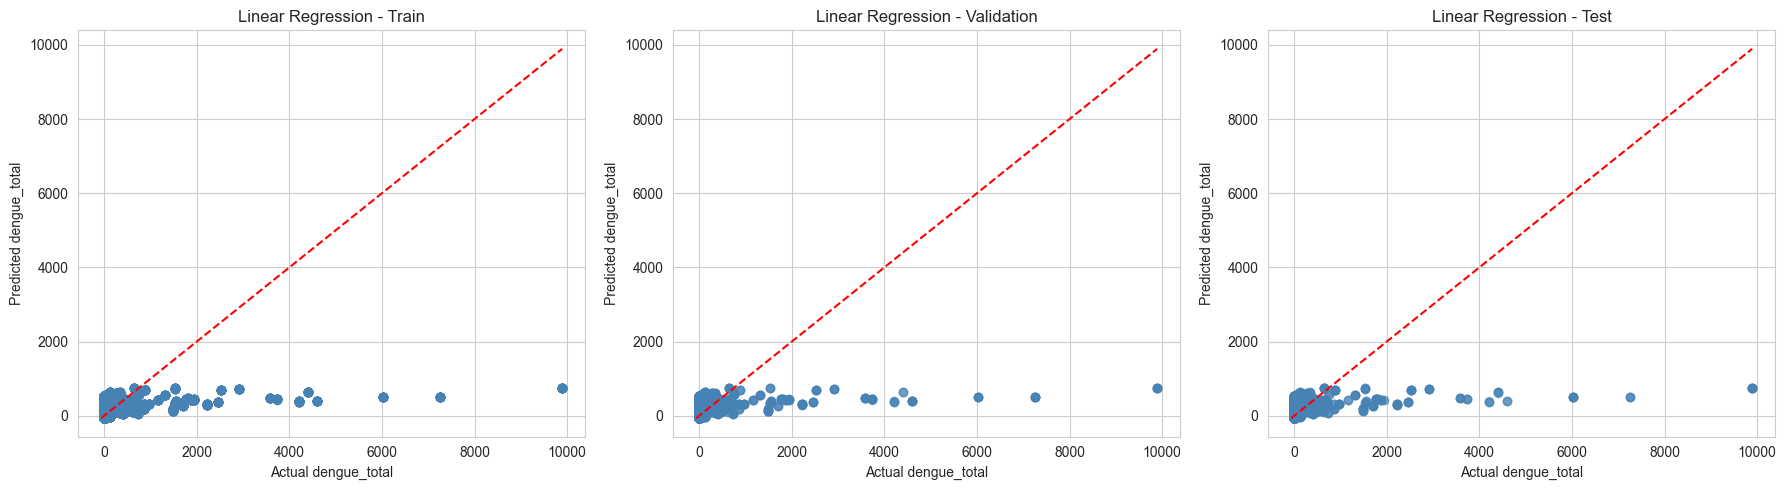

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_val, y_test],
    [linear_y_train_pred, linear_y_val_pred, linear_y_test_pred],
    ["Train", "Validation", "Test"]
):
    ax.scatter(y_true, y_pred, alpha=0.4, color="steelblue")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="red", linestyle="--")
    ax.set_xlabel("Actual dengue_total")
    ax.set_ylabel("Predicted dengue_total")
    ax.set_title(f"Linear Regression - {title}")

plt.tight_layout()
plt.show()

## Lasso Regression Curve: Actual vs Predicted

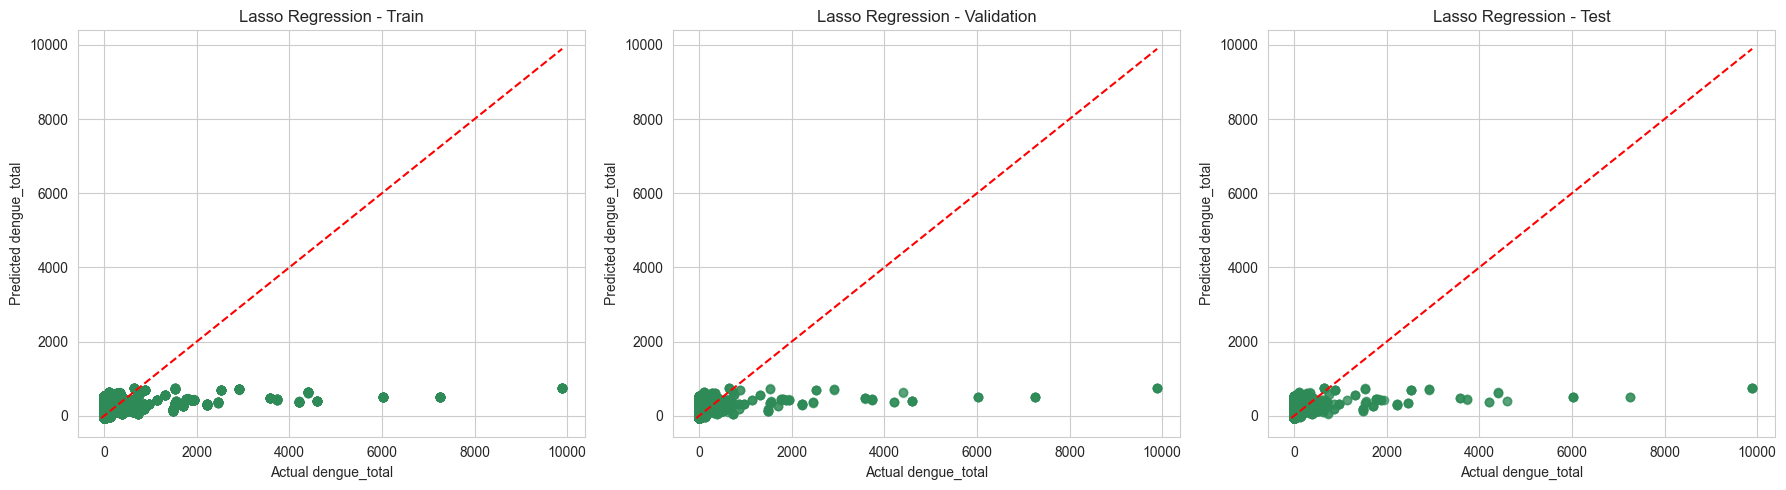

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_val, y_test],
    [lasso_y_train_pred, lasso_y_val_pred, lasso_y_test_pred],
    ["Train", "Validation", "Test"]
):
    ax.scatter(y_true, y_pred, alpha=0.4, color="seagreen")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="red", linestyle="--")
    ax.set_xlabel("Actual dengue_total")
    ax.set_ylabel("Predicted dengue_total")
    ax.set_title(f"Lasso Regression - {title}")

plt.tight_layout()
plt.show()

## Linear vs Lasso: MSE Comparison

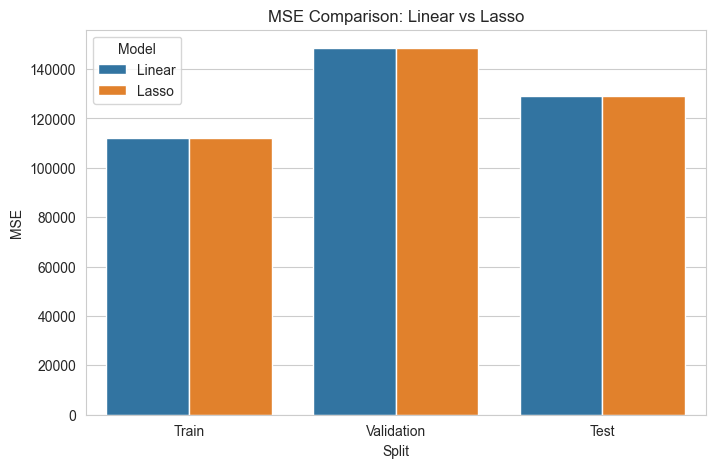

,Split,Model,MSE
0,Train,Linear,112200.815165
1,Validation,Linear,148481.663755
2,Test,Linear,128942.948197
3,Train,Lasso,112201.759322
4,Validation,Lasso,148494.173680
5,Test,Lasso,128944.621708


In [14]:
mse_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"] * 2,
    "Model": ["Linear"] * 3 + ["Lasso"] * 3,
    "MSE": [linear_train_loss, linear_val_loss, linear_test_loss,
            lasso_train_loss, lasso_val_loss, lasso_test_loss]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=mse_df, x="Split", y="MSE", hue="Model")
plt.title("MSE Comparison: Linear vs Lasso")
plt.show()

mse_df

## Linear vs Lasso: R2 Score Comparison

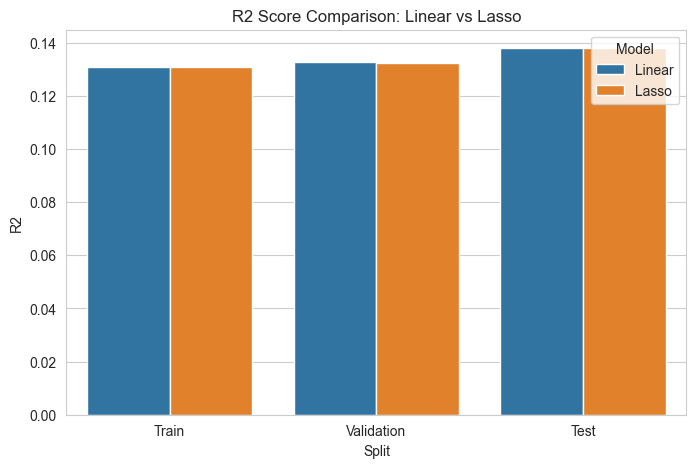

,Split,Model,R2
0,Train,Linear,0.130870
1,Validation,Linear,0.132527
2,Test,Linear,0.137941
3,Train,Lasso,0.130863
4,Validation,Lasso,0.132453
5,Test,Lasso,0.137930


In [15]:
r2_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"] * 2,
    "Model": ["Linear"] * 3 + ["Lasso"] * 3,
    "R2": [linear_train_r2, linear_val_r2, linear_test_r2,
           lasso_train_r2, lasso_val_r2, lasso_test_r2]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=r2_df, x="Split", y="R2", hue="Model")
plt.title("R2 Score Comparison: Linear vs Lasso")
plt.show()

r2_df